In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

## Bloque 1: Conexión y exploración inicial

In [2]:
#Obtencion de servidor Sql

load_dotenv()  # ← carga el .env

DB_SERVER = os.getenv("DB_SERVER")
DB_NAME = os.getenv("DB_NAME")

In [3]:
# Conectar la info del API al SQL y guardar los datos en la base de datos para su posterior análisis.
engine = create_engine(
    f"mssql+pyodbc://{DB_SERVER}/{DB_NAME}"
    f"?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

In [4]:
partidos = pd.read_sql('SELECT * FROM fact_partido',con=engine)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [5]:
partidos.head(3)

,id_partido,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,id_equipo_local,id_equipo_visitante
0,1,2000-09-09,Barcelona,Malaga,2,1,H,2,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,24
1,2,2000-09-09,La Coruna,Ath Bilbao,2,0,H,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,4
2,3,2000-09-09,Real Madrid,Valencia,2,1,H,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,37


In [6]:
partidos['temporada'] = partidos['temporada'].str[:2] + '/' + partidos['temporada'].str[2:]

In [7]:
partidos.shape,partidos.dtypes

((9770, 69),
 id_partido               int64
 Date                    object
 HomeTeam                object
 AwayTeam                object
 FTHG                     int64
                         ...   
 BbMxA                  float64
 BbAvA                  float64
 BbOU                   float64
 id_equipo_local          int64
 id_equipo_visitante      int64
 Length: 69, dtype: object)

In [8]:
partidos.isnull().sum().sort_values(ascending=False)

BFE<2.5                9127
BFE>2.5                9127
BFEC<2.5               9120
BFEC>2.5               9120
GB>2.5                 8683
                       ... 
FTAG                      0
FTHG                      0
AwayTeam                  0
HomeTeam                  0
id_equipo_visitante       0
Length: 69, dtype: int64

In [9]:
umbral = len(partidos) * 0.5
partidos.isnull().sum()[partidos.isnull().sum() > umbral]/len(partidos)*100

Time         73.899693
MaxH         73.899693
MaxD         73.899693
MaxA         73.899693
AvgH         73.899693
AvgD         73.899693
AvgA         73.899693
B365>2.5     64.124872
B365<2.5     64.124872
Max>2.5      73.899693
Max<2.5      73.899693
Avg>2.5      73.899693
Avg<2.5      73.899693
GB>2.5       88.874104
GB<2.5       88.874104
P>2.5        74.810645
P<2.5        74.810645
B365C>2.5    73.899693
B365C<2.5    73.899693
PC>2.5       74.759468
PC<2.5       74.759468
MaxC>2.5     73.899693
MaxC<2.5     73.899693
AvgC>2.5     73.899693
AvgC<2.5     73.899693
BFE>2.5      93.418628
BFE<2.5      93.418628
BFEC>2.5     93.346981
BFEC<2.5     93.346981
dtype: float64

In [10]:
partidos['Date'] = pd.to_datetime(partidos['Date'])
partidos.groupby('temporada').size()

temporada
00/01    380
01/02    380
02/03    380
03/04    380
04/05    380
05/06    380
06/07    380
07/08    380
08/09    380
09/10    380
10/11    380
11/12    380
12/13    380
13/14    380
14/15    380
15/16    380
16/17    380
17/18    380
18/19    380
19/20    380
20/21    380
21/22    380
22/23    380
23/24    380
24/25    380
25/26    270
dtype: int64

In [11]:
# Ver desde qué temporada hay odds (usando B365H como referencia)
partidos.groupby('temporada')['B365H'].count()

temporada
00/01      0
01/02      0
02/03    379
03/04    375
04/05    380
05/06    380
06/07    380
07/08    380
08/09    380
09/10    380
10/11    380
11/12    380
12/13    380
13/14    380
14/15    380
15/16    380
16/17    380
17/18    380
18/19    380
19/20    380
20/21    380
21/22    380
22/23    380
23/24    380
24/25    380
25/26    270
Name: B365H, dtype: int64

In [12]:
# DataFrame completo — para análisis históricos (tendencias, equipos)
df_full = partidos.copy()

temporadas_excluir = ['00/01', '01/02']

df_model = partidos[~partidos['temporada'].isin(temporadas_excluir)].copy()

print(f"df_full:  {len(df_full)} partidos")
print(f"df_model: {len(df_model)} partidos")

df_full:  9770 partidos
df_model: 9010 partidos


In [13]:
# 1. Distribución absoluta y porcentual
dist = df_full['FTR'].value_counts()
dist_pct = df_full['FTR'].value_counts(normalize=True) * 100

print(dist)
print(dist_pct.round(1))

FTR
H    4595
A    2708
D    2467
Name: count, dtype: int64
FTR
H    47.0
A    27.7
D    25.3
Name: proportion, dtype: float64


## Bloque 2: Distribución de resultados

In [14]:
# 2. ¿Esa distribución cambió con el tiempo?
df_full.groupby('temporada')['FTR'].value_counts(normalize=True).unstack().round(3)*100

FTR,A,D,H
temporada,,,
00/01,21.6,26.1,52.4
01/02,24.5,26.6,48.9
02/03,26.1,27.6,46.3
03/04,29.7,25.0,45.3
04/05,23.2,26.3,50.5
05/06,29.7,27.6,42.6
06/07,28.9,25.8,45.3
07/08,29.2,22.9,47.9
08/09,29.7,21.8,48.4


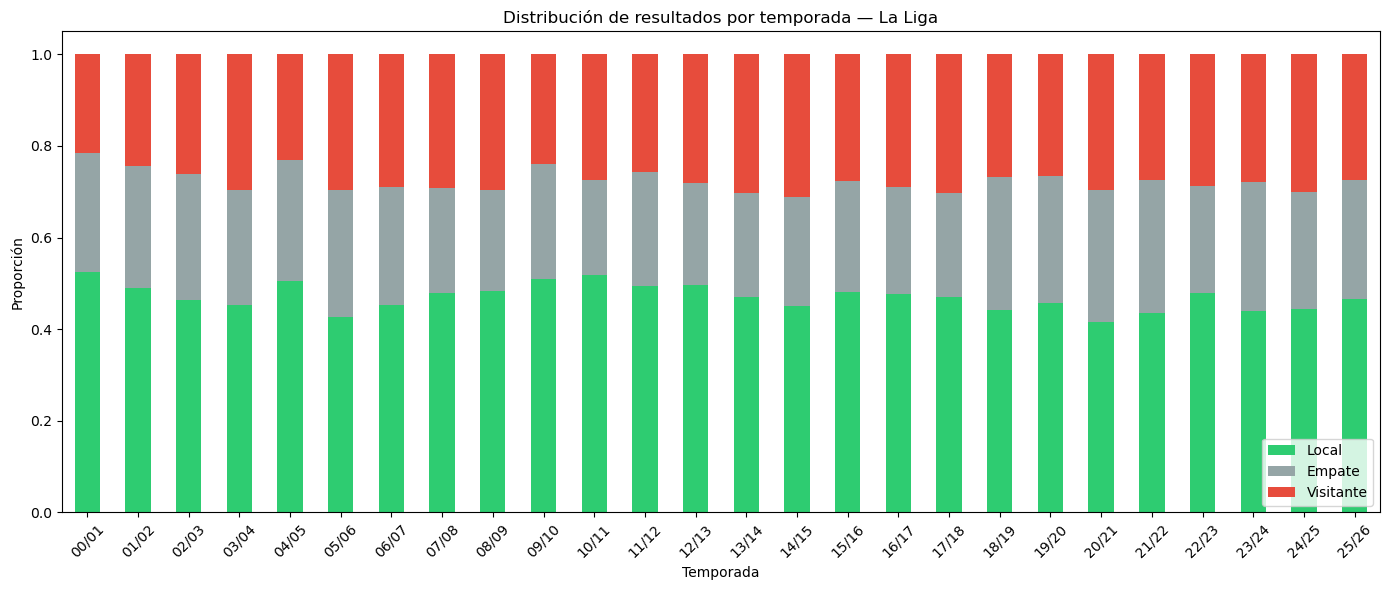

In [15]:
dist_temp = df_full.groupby('temporada')['FTR'].value_counts(normalize=True).unstack()

dist_temp[['H','D','A']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(14,6),
    color=['#2ecc71','#95a5a6','#e74c3c']
)

plt.title('Distribución de resultados por temporada — La Liga')
plt.xlabel('Temporada')
plt.ylabel('Proporción')
plt.xticks(rotation=45)
plt.legend(['Local', 'Empate', 'Visitante'], loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
df_full['temporada'].unique()

array(['00/01', '01/02', '02/03', '03/04', '04/05', '05/06', '06/07',
       '07/08', '08/09', '09/10', '10/11', '11/12', '12/13', '13/14',
       '14/15', '15/16', '16/17', '17/18', '18/19', '19/20', '20/21',
       '21/22', '22/23', '23/24', '24/25', '25/26'], dtype=object)

In [17]:
covid_mapp = {
    '00/01': 'Antes de Covid',
    '01/02': 'Antes de Covid',
    '02/03': 'Antes de Covid',
    '03/04': 'Antes de Covid',
    '04/05': 'Antes de Covid',
    '05/06': 'Antes de Covid',
    '06/07':'Antes de Covid',
    '07/08': 'Antes de Covid',
    '08/09': 'Antes de Covid',
    '09/10': 'Antes de Covid',
    '10/11': 'Antes de Covid',
    '11/12': 'Antes de Covid',
    '12/13': 'Antes de Covid',
    '13/14':'Antes de Covid',
    '14/15': 'Antes de Covid',
    '15/16': 'Antes de Covid',
    '16/17': 'Antes de Covid',
    '17/18': 'Antes de Covid',
    '18/19': 'Antes de Covid',
    '19/20': 'Antes de Covid',
    '20/21':'Durante de Covid',
    '21/22': 'Despues de Covid',
    '22/23': 'Despues de Covid',
    '23/24': 'Despues de Covid',
    '24/25': 'Despues de Covid',
    '25/26':'Despues de Covid'
}

In [18]:
df_full['Pandemia'] = df_full['temporada'].map(covid_mapp)

In [19]:
df_full.groupby('Pandemia')['temporada'].unique()

Pandemia
Antes de Covid      [00/01, 01/02, 02/03, 03/04, 04/05, 05/06, 06/...
Despues de Covid                  [21/22, 22/23, 23/24, 24/25, 25/26]
Durante de Covid                                              [20/21]
Name: temporada, dtype: object

In [20]:
# 2. ¿Esa distribución cambió con el tiempo?
df_full.groupby('Pandemia')['FTR'].value_counts(normalize=True).unstack().round(3)*100

FTR,A,D,H
Pandemia,,,
Antes de Covid,27.5,24.8,47.7
Despues de Covid,28.3,26.5,45.2
Durante de Covid,29.7,28.7,41.6


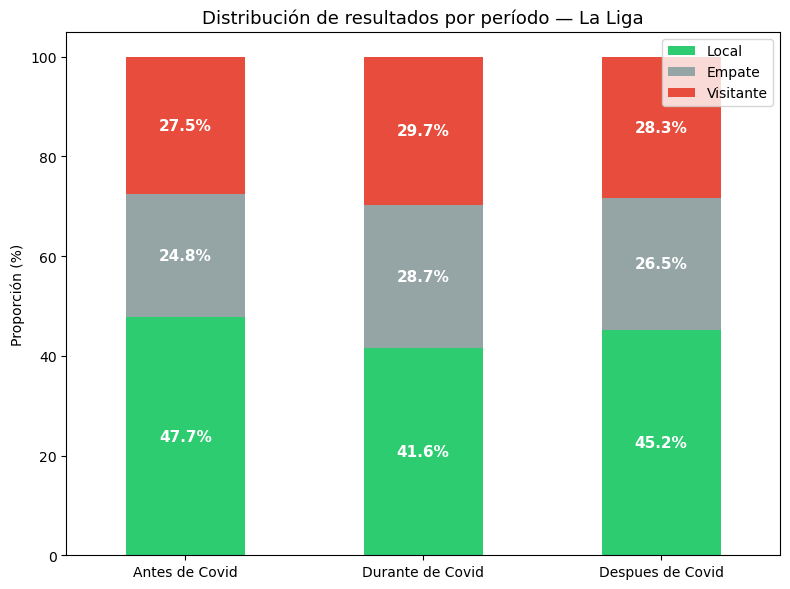

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

# Datos
dist_covid = df_full.groupby('Pandemia')['FTR']\
    .value_counts(normalize=True).unstack()[['H','D','A']] * 100

# Orden de períodos
orden = ['Antes de Covid', 'Durante de Covid', 'Despues de Covid']
dist_covid = dist_covid.loc[orden]

# Graficar
dist_covid.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71','#95a5a6','#e74c3c'],
    width=0.5
)

# Anotar valores
for i, (idx, row) in enumerate(dist_covid.iterrows()):
    acumulado = 0
    for col, color in zip(['H','D','A'], ['#2ecc71','#95a5a6','#e74c3c']):
        valor = row[col]
        ax.text(
            i,                        # posición x (barra)
            acumulado + valor / 2,    # posición y (centro del segmento)
            f'{valor:.1f}%',          # texto
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white'
        )
        acumulado += valor

ax.set_title('Distribución de resultados por período — La Liga', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Proporción (%)')
ax.set_xticklabels(orden, rotation=0)
ax.legend(['Local','Empate','Visitante'], loc='upper right')
plt.tight_layout()
plt.show()

**Hallazgos — Impacto COVID en ventaja local**

- Sin público (20/21), la victoria local cayó de 47.7% a 41.6% (-6.1 pp)
- Los empates aumentaron durante COVID: de 24.8% a 26.5%
- Post-COVID la ventaja local no se recuperó completamente (45.2%)
- Conclusión: el público es una variable relevante para el modelo predictivo

## Bloque 3: Rendimiento por equipo

In [22]:
df_full.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['id_partido', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG', 'HTR', 'temporada', 'Time', 'HS', 'AS', 'HST', 'AST',
       'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D',
       'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5',
       'B365<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'GB>2.5',
       'GB<2.5', 'P>2.5', 'P<2.5', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5',
       'BbAv<2.5', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5',
       'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'BFE>2.5', 'BFE<2.5', 'BFEC>2.5',
       'BFEC<2.5', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA',
       'BbAvA', 'BbOU', 'id_equipo_local', 'id_equipo_visitante', 'Pandemia'],
      dtype='object')>

In [23]:
df_goles_local = df_full[['temporada','HomeTeam','FTHG']].rename(columns={'HomeTeam':'Equipo','FTHG':'Goles'}) # Se saca la info del equipo local, sus goles y temporada
df_goles_local['Condicion'] = 'Local' # se agrega de que condicion juegan el partido
df_goles_visitante = df_full[['temporada','AwayTeam','FTAG']].rename(columns={'AwayTeam':'Equipo','FTAG':'Goles'}) # Se saca la info del equipo Visitante, sus goles y temporada
df_goles_visitante['Condicion'] = 'Visitante'
df_goles_global = pd.concat([df_goles_local,df_goles_visitante]) # se une la info en una sola bd para poder analizar


In [24]:
df_goles_global

,temporada,Equipo,Goles,Condicion
0,00/01,Barcelona,2,Local
1,00/01,La Coruna,2,Local
2,00/01,Real Madrid,2,Local
3,00/01,Sociedad,2,Local
4,00/01,Zaragoza,1,Local
...,...,...,...,...
9765,25/26,Elche,1,Visitante
9766,25/26,Betis,0,Visitante
9767,25/26,Vallecano,1,Visitante
9768,25/26,Alaves,2,Visitante


Media de goles por partido en todas las temporadas

In [25]:
df_mean_por_partido = pd.DataFrame(df_goles_global.groupby(['Equipo','temporada'])['Goles'].mean().reset_index())

In [26]:
df_mean_por_partido.groupby('Equipo')['Goles'].mean().sort_values(ascending=False)

Equipo
Barcelona      2.351552
Real Madrid    2.268031
Ath Madrid     1.602786
Villarreal     1.476179
Sevilla        1.459220
Valencia       1.435448
Girona         1.374594
Sociedad       1.351598
Ath Bilbao     1.296784
Celta          1.285624
Betis          1.269272
La Coruna      1.246711
Malaga         1.190789
Zaragoza       1.188995
Mallorca       1.185083
Vallecano      1.152256
Espanol        1.146767
Santander      1.126794
Levante        1.118973
Eibar          1.116541
Almeria        1.105263
Osasuna        1.084973
Getafe         1.073146
Recreativo     1.072368
Sp Gijon       1.061404
Las Palmas     1.041353
Granada        1.026316
Alaves         1.016569
Huesca         1.013158
Valladolid     1.013158
Xerez          1.000000
Oviedo         0.985867
Albacete       0.960526
Elche          0.957277
Numancia       0.947368
Hercules       0.947368
Tenerife       0.947368
Leganes        0.926316
Gimnastic      0.894737
Cadiz          0.857895
Murcia         0.855263
Cordoba  

Goles marcados por temporadas

In [27]:
df_goles_por_temporada = pd.DataFrame(df_goles_global.groupby(['Equipo','temporada'])['Goles'].sum().reset_index())
# Paso 2 — media de goles por temporada jugada
goles_media = df_goles_por_temporada.groupby('Equipo')['Goles'].mean().sort_values(ascending=False)

goles_media.head(10)

Equipo
Barcelona      88.230769
Real Madrid    85.307692
Ath Madrid     60.125000
Villarreal     55.280000
Sevilla        54.880000
Valencia       54.076923
Sociedad       50.652174
Girona         50.333333
Ath Bilbao     48.807692
Celta          48.100000
Name: Goles, dtype: float64

In [28]:
df_goles_media = pd.DataFrame(df_goles_por_temporada.groupby('Equipo')['Goles'].mean().sort_values(ascending=False))

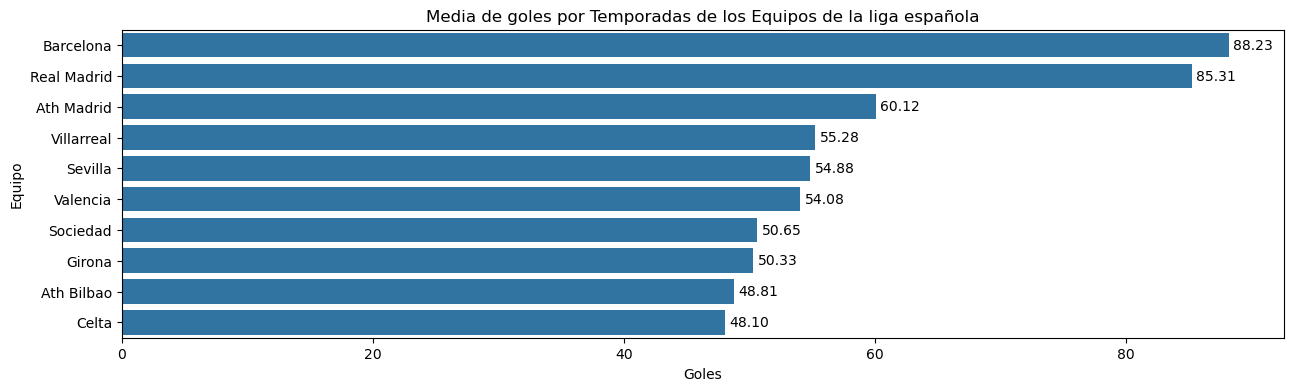

In [29]:
plt.figure(figsize=(15,4))
plt.title('Media de goles por Temporadas de los Equipos de la liga española')
ax = sns.barplot(data=df_goles_media.head(10), y='Equipo', x='Goles')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.show()

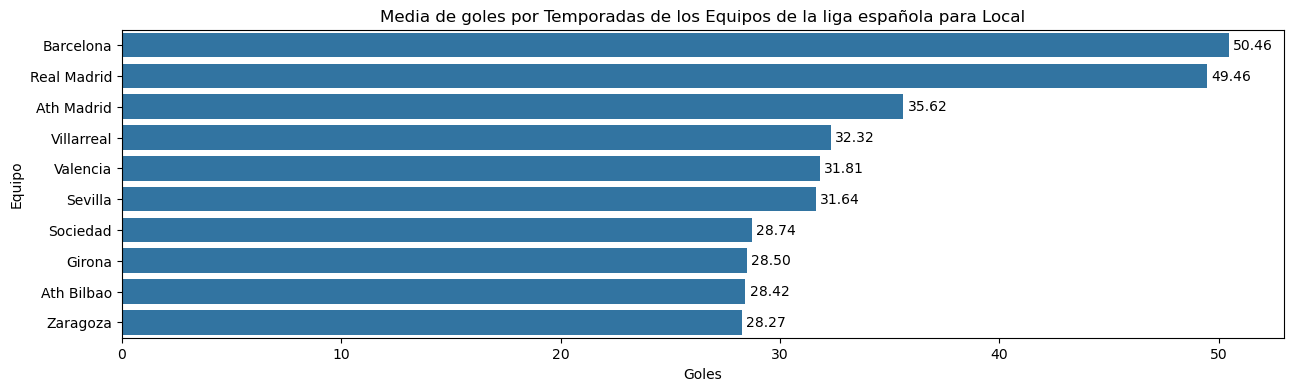

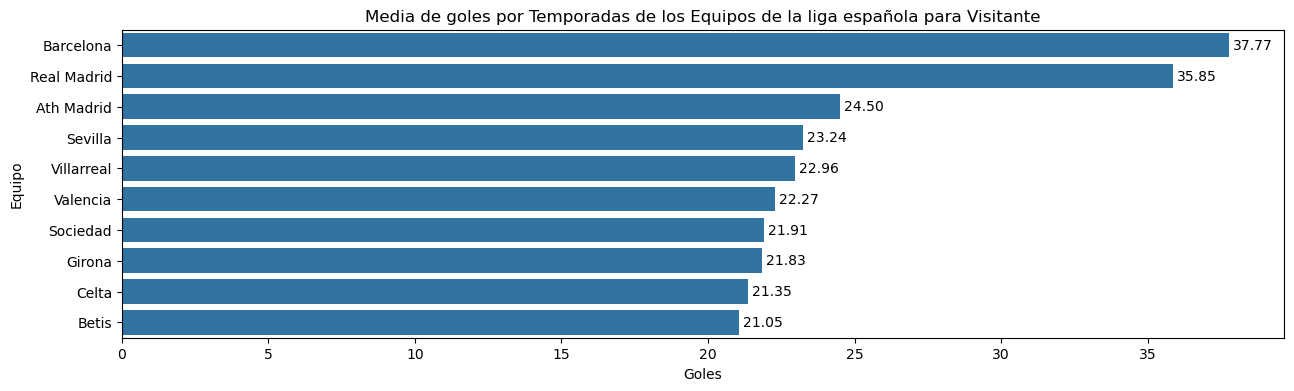

In [30]:
for cond in df_goles_global['Condicion'].unique():
    df_filtro = df_goles_global[df_goles_global['Condicion'] == cond]
    df_sum = pd.DataFrame(df_filtro.groupby(['Equipo','temporada'])['Goles'].sum().reset_index())
    df_prom = pd.DataFrame(df_sum.groupby('Equipo')['Goles'].mean().sort_values(ascending=False))
    plt.figure(figsize=(15,4))
    plt.title(f'Media de goles por Temporadas de los Equipos de la liga española para {cond}')
    ax = sns.barplot(data=df_prom.head(10), y='Equipo', x='Goles')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    plt.show()
    
    

- Los equipos top meten más goles de local que de visitante (Barcelona: 50 vs 37)
- Equipos como Zaragoza son fuertes de local pero conservadores de visitante
- El contexto local/visitante modifica el comportamiento ofensivo del equipo
- Esto sugiere que local/visitante debe ser una feature del modelo

In [31]:
# 1. Create two views of the same match
# Local View
df_local = df_full[['temporada', 'HomeTeam', 'FTHG', 'FTR']].copy()
df_local.columns = ['temporada', 'Equipo', 'Goles', 'Res']
df_local['Condicion'] = 'Local'

# Visitor View (We must invert the result for the visitor)
df_visitante = df_full[['temporada', 'AwayTeam', 'FTAG', 'FTR']].copy()
df_visitante.columns = ['temporada', 'Equipo', 'Goles', 'Res']
df_visitante['Condicion'] = 'Visitante'

# Logic: If Result was 'V' (local Win), for the Visitor it's 'D' (Loss)
res_local     = {'H': 'Victoria', 'D': 'Empate', 'A': 'Derrota'}
res_visitante = {'A': 'Victoria', 'D': 'Empate', 'H': 'Derrota'}
df_visitante['Res'] = df_visitante['Res'].map(res_visitante)
df_local['Res'] = df_local['Res'].map(res_local)
# 2. Combine them
df_final = pd.concat([df_local, df_visitante], ignore_index=True)

df_final

,temporada,Equipo,Goles,Res,Condicion
0,00/01,Barcelona,2,Victoria,Local
1,00/01,La Coruna,2,Victoria,Local
2,00/01,Real Madrid,2,Victoria,Local
3,00/01,Sociedad,2,Empate,Local
4,00/01,Zaragoza,1,Derrota,Local
...,...,...,...,...,...
19535,25/26,Elche,1,Derrota,Visitante
19536,25/26,Betis,0,Derrota,Visitante
19537,25/26,Vallecano,1,Empate,Visitante
19538,25/26,Alaves,2,Derrota,Visitante


In [32]:
prueba = pd.DataFrame(
    df_final.pivot_table(
    index=['temporada','Equipo','Condicion'],
    columns='Res',
    aggfunc={'Res':'count'},
    fill_value=0)
)

In [33]:
# Usamos crosstab para las frecuencias (V, E, D)
conteo_res = pd.crosstab(
    index=[df_final['temporada'], df_final['Equipo'], df_final['Condicion']], 
    columns=df_final['Res']
).reset_index()

In [34]:
# Assuming 'conteo_res' has columns: V, E, D
conteo_res['Total_Partidos'] = conteo_res[['Derrota','Empate','Victoria']].sum(axis=1)

# Calculate specific percentages
conteo_res['%_Victorias'] = (conteo_res['Victoria'] / conteo_res['Total_Partidos']) * 100
conteo_res['%_Empates'] = (conteo_res['Empate'] / conteo_res['Total_Partidos']) * 100
conteo_res['%_Derrotas'] = (conteo_res['Derrota'] / conteo_res['Total_Partidos']) * 100

# Round for better readability
conteo_res = conteo_res.round(2)


In [36]:
lista = ['Derrota','Empate','Victoria','Total_Partidos']
df_equipo_resultado = conteo_res.groupby('Equipo')[lista].sum().reset_index()

In [37]:
df_equipo_resultado['%_Victorias'] = np.round((df_equipo_resultado['Victoria']/df_equipo_resultado['Total_Partidos'])*100,2)
df_equipo_resultado['%_Derrotas'] = np.round((df_equipo_resultado['Derrota']/df_equipo_resultado['Total_Partidos'])*100,2)
df_equipo_resultado['%_Empate'] = np.round((df_equipo_resultado['Empate']/df_equipo_resultado['Total_Partidos'])*100,2)

In [38]:
df_equipo_resultado.sort_values(by = '%_Victorias',ascending=False)

Res,Equipo,Derrota,Empate,Victoria,Total_Partidos,%_Victorias,%_Derrotas,%_Empate
29,Real Madrid,152,168,657,977,67.25,15.56,17.20
5,Barcelona,140,185,652,977,66.73,14.33,18.94
4,Ath Madrid,218,209,474,901,52.61,24.20,23.20
32,Sevilla,300,223,416,939,44.30,31.95,23.75
39,Villarreal,292,242,405,939,43.13,31.10,25.77
36,Valencia,299,261,417,977,42.68,30.60,26.71
33,Sociedad,319,216,328,863,38.01,36.96,25.03
3,Ath Bilbao,346,264,367,977,37.56,35.41,27.02
15,Girona,85,53,79,217,36.41,39.17,24.42
19,La Coruna,224,169,215,608,35.36,36.84,27.80


In [39]:
df_equipo_resultado.sort_values(by = '%_Victorias',ascending=False).reset_index().head(10)

Res,index,Equipo,Derrota,Empate,Victoria,Total_Partidos,%_Victorias,%_Derrotas,%_Empate
0,29,Real Madrid,152,168,657,977,67.25,15.56,17.20
1,5,Barcelona,140,185,652,977,66.73,14.33,18.94
2,4,Ath Madrid,218,209,474,901,52.61,24.20,23.20
3,32,Sevilla,300,223,416,939,44.30,31.95,23.75
4,39,Villarreal,292,242,405,939,43.13,31.10,25.77
5,36,Valencia,299,261,417,977,42.68,30.60,26.71
6,33,Sociedad,319,216,328,863,38.01,36.96,25.03
7,3,Ath Bilbao,346,264,367,977,37.56,35.41,27.02
8,15,Girona,85,53,79,217,36.41,39.17,24.42
9,19,La Coruna,224,169,215,608,35.36,36.84,27.80


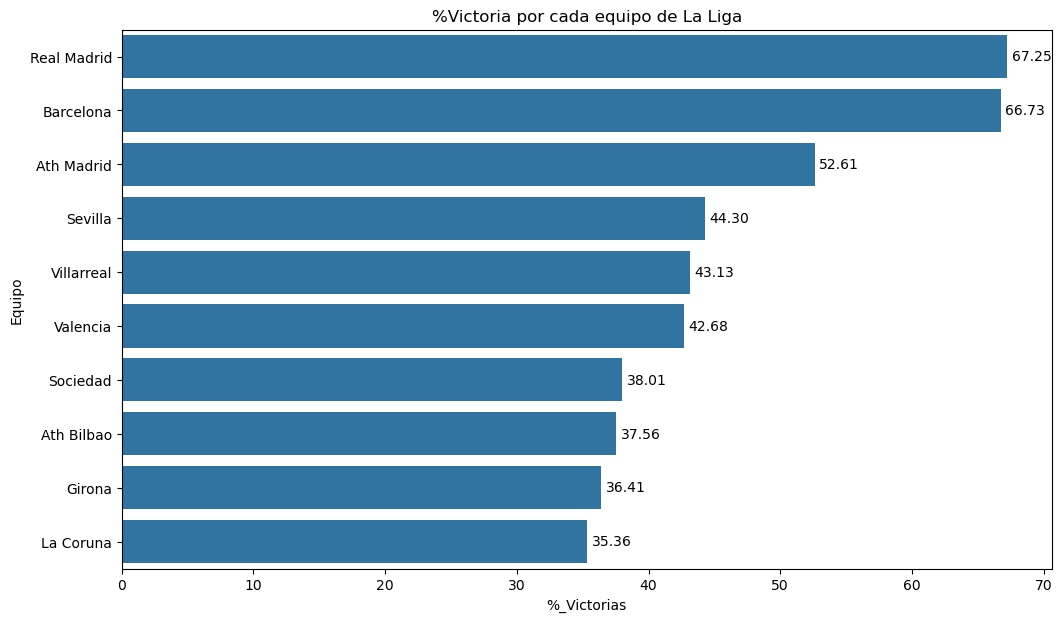

In [40]:
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data = df_equipo_resultado.sort_values('%_Victorias', ascending=False).head(10),
    y = 'Equipo',
    x = '%_Victorias')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.title("%Victoria por cada equipo de La Liga")
plt.show()

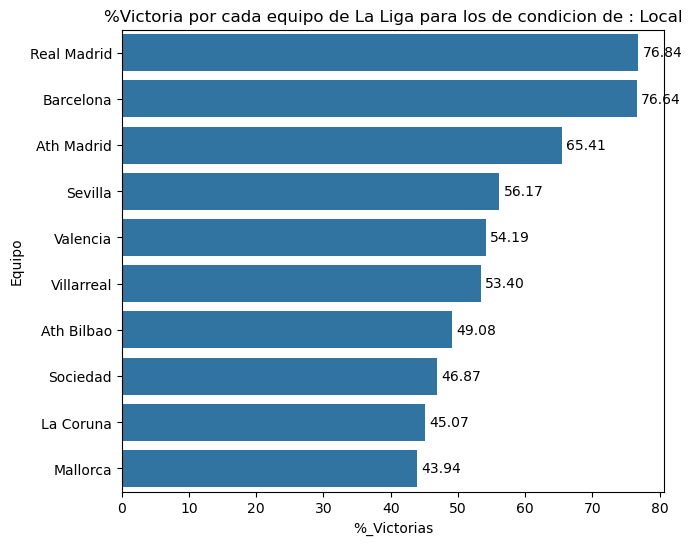

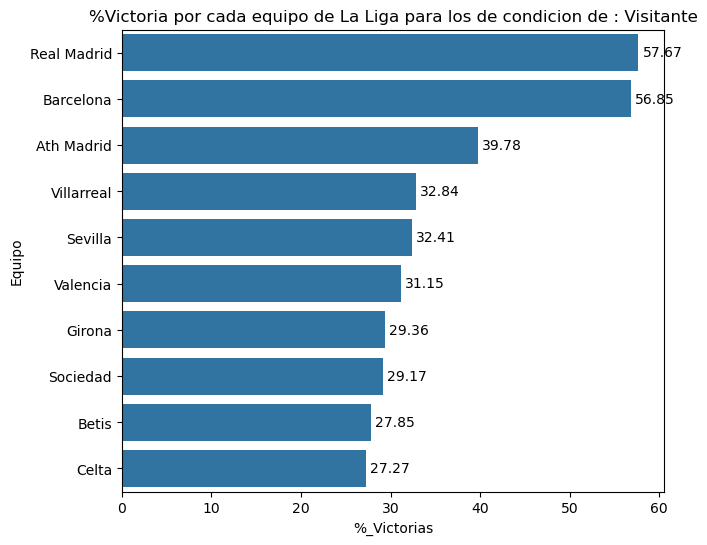

In [41]:
for cond in conteo_res['Condicion'].unique():
    df_ = conteo_res[conteo_res['Condicion']==cond]
    df_cond_ = df_.groupby('Equipo')[lista].sum().reset_index()
    df_cond_['%_Victorias'] = np.round((df_cond_['Victoria']/df_cond_['Total_Partidos'])*100,2)
    df_cond_['%_Derrotas'] = np.round((df_cond_['Derrota']/df_cond_['Total_Partidos'])*100,2)
    df_cond_['%_Empate'] = np.round((df_cond_['Empate']/df_cond_['Total_Partidos'])*100,2)
    plt.figure(figsize=(7,6))
    ax = sns.barplot(
        data = df_cond_.sort_values('%_Victorias', ascending=False).head(10),
        y = 'Equipo',
        x = '%_Victorias')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    plt.title(f"%Victoria por cada equipo de La Liga para los de condicion de : {cond}")
    plt.show()

**Hallazgos — Rendimiento por equipo**

- Real Madrid (67.2%) y Barcelona (66.8%) dominan con ~15pp de ventaja sobre el resto
- Atlético de Madrid forma un segundo nivel claro con 52.8% de victorias
- El pelotón (Sevilla, Villarreal, Valencia) se agrupa entre 43-44%
- Los equipos top también lideran en goles por temporada — relación que se validará en Bloque 5
- Girona y La Coruna aparecen en top 10 con pocas temporadas — sus métricas deben interpretarse con cautela

## Bloque 4: Tendencias estacionales

In [49]:
df_full.groupby('temporada')[['HS','HY','HC']].apply(lambda x: x.isnull().sum().sum())

temporada
00/01    1140
01/02    1140
02/03    1140
03/04    1140
04/05    1140
05/06       0
06/07       0
07/08       0
08/09       0
09/10       0
10/11       0
11/12       0
12/13       0
13/14       0
14/15       0
15/16       0
16/17       0
17/18       0
18/19       0
19/20       0
20/21       0
21/22       0
22/23       0
23/24       0
24/25       0
25/26       0
dtype: int64

In [ ]:
df_full['Goles totales'] = df_full['FTHG'] + df_full['FTAG']
df_full['Tiros totales'] = df_full['HS'] + df_full['AS']
df_full['Tarjetas amarillas'] = df_full['HY'] + df_full['AY']
df_full['Total Corners'] = df_full['HC'] + df_full['AC']


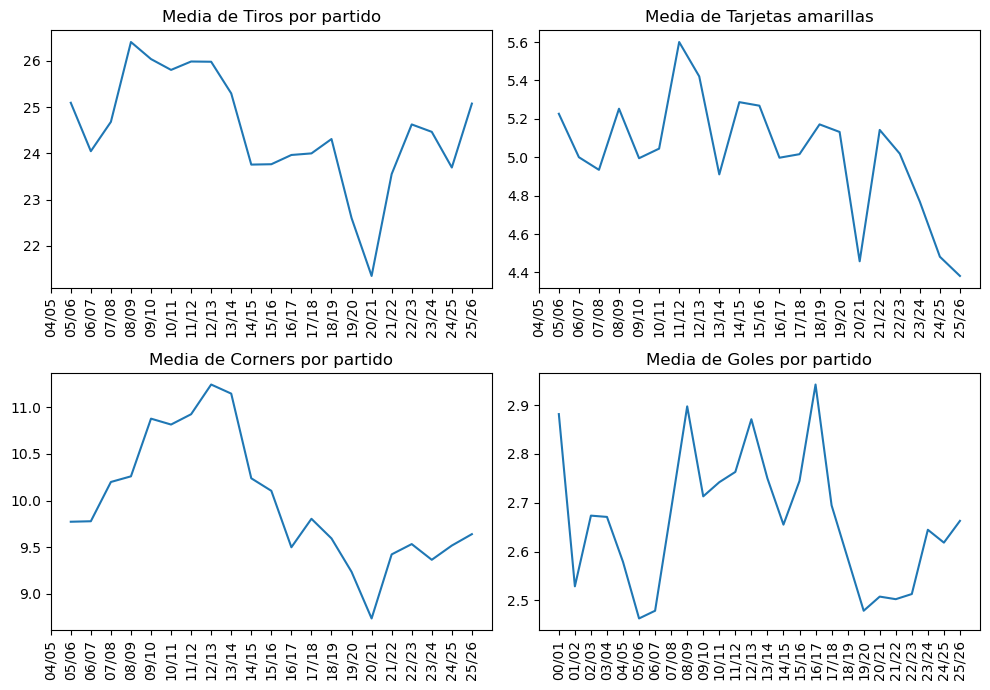

In [59]:
# Definimos una figura
plt.figure(figsize=(10, 7))

# Gráfico 1
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.set_title("Media de Tiros por partido")
ax1.plot(df_full.groupby('temporada')['Tiros totales'].mean())
ax1.tick_params(axis='x', rotation=90) # <--- Gira las etiquetas 90 grados

# Gráfico 2
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.set_title("Media de Tarjetas amarillas")
ax2.plot(df_full.groupby('temporada')['Tarjetas amarillas'].mean())
ax2.tick_params(axis='x', rotation=90) # <--- Gira las etiquetas 90 grados

# Gráfico 3
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax3.set_title("Media de Corners por partido")
ax3.plot(df_full.groupby('temporada')['Total Corners'].mean())
ax3.tick_params(axis='x', rotation=90) # <--- Gira las etiquetas 90 grados

# Gráfico 3
ax4 = plt.subplot2grid((2, 2), (1, 1))
ax4.set_title("Media de Goles por partido")
ax4.plot(df_full.groupby('temporada')['Goles totales'].mean())
ax4.tick_params(axis='x', rotation=90) # <--- Gira las etiquetas 90 grados
plt.tight_layout()
plt.show()


* Se tiene informacion de los corner, tarjetas y tiros a partir de la campaña 05/06

1. Se observa que los goles, tienen una tendencia ciclica pero a partir del covid no se llega a recuperar la cantidad de goles que llega a marcar los equipos
2. los tiros por partido se llega a tener una tendencia de estar por encima de 24 con excepcion de la pandemia,se ve una tendencia a la baja desde la 05/06 pero posterior a la pandemia se esta aumentando los tiros.
    El pico de tiros es alrededor de 08/09 (~26.5) y de ahí viene la bajada.
3. las tarjetas estan reduciendose a lo largo de las campañas
4. Los cornes sigue la misma tendendia a la baja, pero se esta viendo que hay ya una tendencia a aumentar despues de la pandemia

las cuatro métricas coinciden en su mínimo en 20/21 (COVID). Eso no es casualidad — sin público, los partidos fueron menos intensos en todas las dimensiones.
la correlación entre tiros y corners tiene sentido lógico (más ataque → más corners), lo cual sugiere que durante el feature engineering estas variables podrían tener multicolinealidad — algo a tener en cuenta cuando se realice el modelo.